# Heart Disease Prediction Project
**Goal:** Predict presence of heart disease using Cleveland dataset with Logistic Regression and Decision Tree.

**Dataset:** Cleveland Heart Disease Dataset - 297 patients, 13 features

In [31]:
# === STEP 1: IMPORT ALL REQUIRED LIBRARIES ===
# These libraries are needed for data handling, ML models, and visualization

# pandas: Used for loading CSV data and creating dataframes for analysis
import pandas as pd

# numpy: Used for numerical operations and array handling
import numpy as np

# matplotlib.pyplot: Used for creating basic plots and graphs
import matplotlib.pyplot as plt

# seaborn: Used for advanced statistical data visualization like countplot, barplot
import seaborn as sns

# sklearn modules will be imported later before model training
# This keeps the notebook organized step by step

print("Libraries loaded successfully ✅")

Libraries loaded successfully ✅


In [32]:
# === STEP 2: LOAD THE CLEVELAND HEART DISEASE DATASET ===
# Loading the CSV file into a pandas DataFrame named 'df'
df = pd.read_csv('heart_cleveland_upload.csv')

print("File loaded successfully ✅")
print("Dataset Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Display the first 5 rows to verify data is loaded correctly
# This helps us check column names and initial data structure
df.head()

File loaded successfully ✅
Dataset Shape: (297, 14)
Rows: 297
Columns: 14


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [33]:
# === STEP 3: CHECK DATASET INFORMATION AND DATA QUALITY ===
# This step verifies column names, data types, and checks for missing values

# Display all column names in the dataset
print("=== COLUMN NAMES ===")
print(df.columns.tolist())

# Check for missing values in each column
# Missing values can cause errors during model training
print("\n=== MISSING VALUES CHECK ===")
print(df.isnull().sum())

# Display complete dataset information
# This shows data types, non-null counts, and memory usage for each column
print("\n=== DATASET INFO ===")
df.info()

=== COLUMN NAMES ===
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition']

=== MISSING VALUES CHECK ===
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64

=== DATASET INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10 

In [34]:
# === STEP 4: CONVERT TARGET VARIABLE TO BINARY CLASSIFICATION ===
# The original dataset uses 'condition' column: 0 = No Disease, 1 = Disease
# We create a new 'target' column for cleaner binary classification: 0 or 1

# Check the unique values in 'condition' column before conversion
print("Before:", df['condition'].unique())

# Convert to binary: 0 remains 0 (No Disease), any value >0 becomes 1 (Disease)
# This simplifies the problem to binary classification
df['target'] = df['condition'].apply(lambda x: 0 if x == 0 else 1)

# Verify the new 'target' column has only 0 and 1
print("After:", df['target'].unique())

# Display the count of patients with and without heart disease
# This shows class distribution and checks for class imbalance
print("\nTarget Count:")
print(df['target'].value_counts())

Before: [0 1]
After: [0 1]

Target Count:
target
0    160
1    137
Name: count, dtype: int64


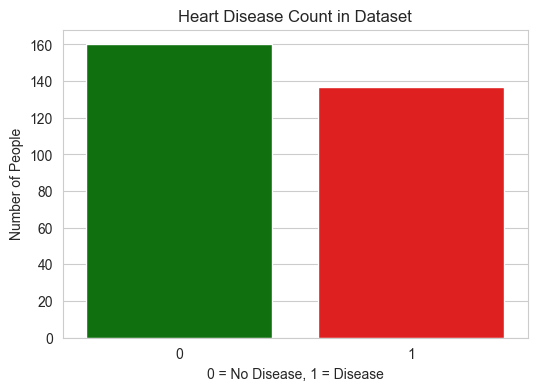

In [35]:
# === STEP 5: VISUALIZE TARGET VARIABLE DISTRIBUTION ===
# This bar chart shows the count of patients with vs without heart disease
# It helps us understand if the dataset is balanced or imbalanced

# Set figure size for better visibility
plt.figure(figsize=(6,4))

# Create countplot for 'target' column
# hue='target' added to fix FutureWarning in seaborn
# palette: green for No Disease (0), red for Disease (1)
sns.countplot(x='target', data=df, hue='target', palette=['green','red'], legend=False)

# Add title and labels for clear interpretation
plt.title('Heart Disease Count in Dataset')
plt.xlabel('0 = No Disease, 1 = Disease')
plt.ylabel('Number of People')

# Display the plot
plt.show()

In [36]:
# === STEP 6 + 7: MODEL TRAINING AND EVALUATION ===
# We will train two models: Logistic Regression and Decision Tree
# Then compare their accuracy and confusion matrix

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# === STEP 6.1: PREPARE DATA FOR MACHINE LEARNING ===
# Drop 'condition' (old column) and 'target' (our label) to create features X
# 'target' column becomes our y variable that we want to predict
X = df.drop(['condition', 'target'], axis=1)
y = df['target']

# === STEP 6.2: SPLIT DATA INTO TRAINING AND TESTING SETS ===
# 80% data for training the model, 20% for testing its performance
# random_state=42 ensures same split every time we run the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

# === STEP 7.1: MODEL 1 - LOGISTIC REGRESSION ===
# Logistic Regression is best for binary classification problems
# max_iter=1000 ensures the model converges properly
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

# Calculate accuracy and confusion matrix for Logistic Regression
log_accuracy = accuracy_score(y_test, log_pred)
print("\n=== LOGISTIC REGRESSION RESULTS ===")
print("Accuracy:", round(log_accuracy, 4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, log_pred))

# === STEP 7.2: MODEL 2 - DECISION TREE CLASSIFIER ===
# Decision Tree splits data based on feature importance
# random_state=42 ensures reproducible results
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

# Calculate accuracy and confusion matrix for Decision Tree
tree_accuracy = accuracy_score(y_test, tree_pred)
print("\n=== DECISION TREE RESULTS ===")
print("Accuracy:", round(tree_accuracy, 4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, tree_pred))

# === MODEL COMPARISON ===
print("\n=== ACCURACY COMPARISON ===")
print(f"Logistic Regression: {log_accuracy:.2%}")
print(f"Decision Tree: {tree_accuracy:.2%}")

Training set size: 237
Testing set size: 60

=== LOGISTIC REGRESSION RESULTS ===
Accuracy: 0.7333
Confusion Matrix:
[[23  9]
 [ 7 21]]

=== DECISION TREE RESULTS ===
Accuracy: 0.7667
Confusion Matrix:
[[24  8]
 [ 6 22]]

=== ACCURACY COMPARISON ===
Logistic Regression: 73.33%
Decision Tree: 76.67%


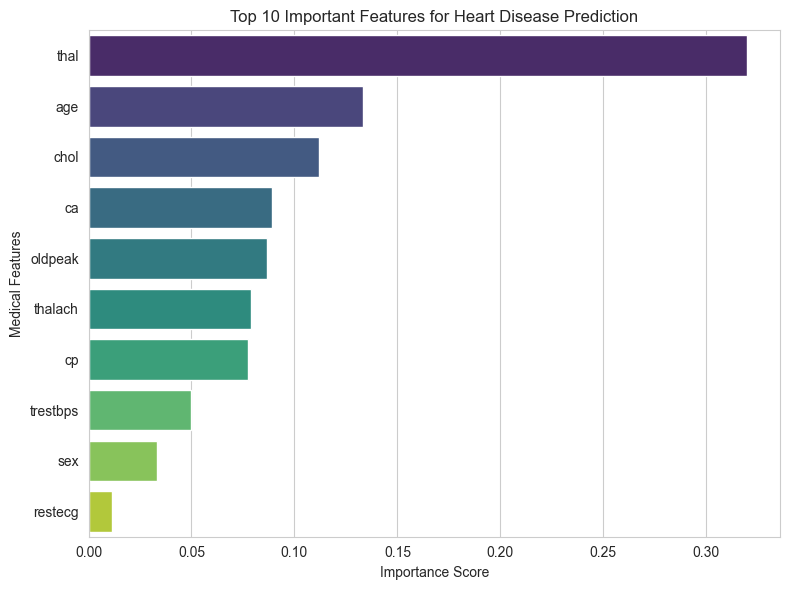

=== TOP 3 IMPORTANT FEATURES ===
   Feature  Importance
12    thal    0.319831
0      age    0.133379
4     chol    0.111855


In [37]:
# === STEP 8: FEATURE IMPORTANCE ANALYSIS USING DECISION TREE ===
# This graph shows which medical features contribute most to heart disease prediction
# Decision Trees calculate importance based on how much each feature reduces impurity

# Create DataFrame with feature names and their importance scores
# feature_importances_ attribute shows the contribution of each feature
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tree_model.feature_importances_
}).sort_values('Importance', ascending=False)

# === PLOT TOP 10 MOST IMPORTANT FEATURES ===
# Visualize which factors doctors should check first for heart disease risk
plt.figure(figsize=(8,6))

# Create horizontal bar plot for top 10 features
# hue='Feature' added to fix FutureWarning, legend=False removes duplicate legend
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10), 
            hue='Feature', legend=False, palette='viridis')

plt.title('Top 10 Important Features for Heart Disease Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Medical Features')
plt.tight_layout()
plt.show()

# Print the top 3 most critical features for quick reference
print("=== TOP 3 IMPORTANT FEATURES ===")
print(feature_importance.head(3))

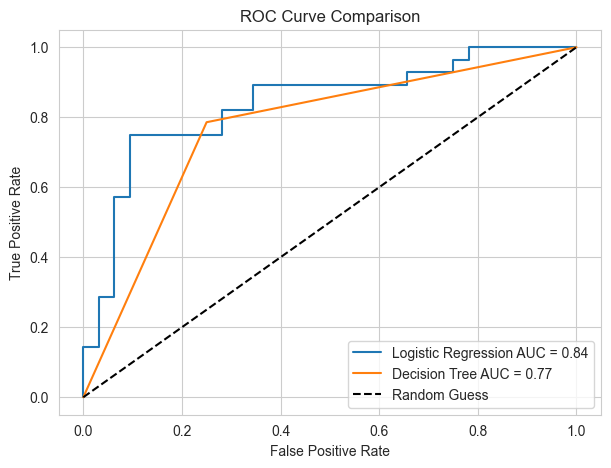

=== AUC SCORES ===
Logistic Regression AUC: 0.838
Decision Tree AUC: 0.768


In [38]:
# === STEP 8: ROC CURVE - LAST STEP ===
from sklearn.metrics import roc_curve, roc_auc_score

# Get probabilities for ROC
log_probs = log_model.predict_proba(X_test)[:, 1]
tree_probs = tree_model.predict_proba(X_test)[:, 1]

# Calculate ROC
log_fpr, log_tpr, _ = roc_curve(y_test, log_probs)
tree_fpr, tree_tpr, _ = roc_curve(y_test, tree_probs)

# Calculate AUC scores
log_auc = roc_auc_score(y_test, log_probs)
tree_auc = roc_auc_score(y_test, tree_probs)

# Plot ROC Curves
plt.figure(figsize=(7,5))
plt.plot(log_fpr, log_tpr, label=f'Logistic Regression AUC = {log_auc:.2f}')
plt.plot(tree_fpr, tree_tpr, label=f'Decision Tree AUC = {tree_auc:.2f}')
plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

print("=== AUC SCORES ===")
print("Logistic Regression AUC:", round(log_auc, 3))
print("Decision Tree AUC:", round(tree_auc, 3))

## Final Results & Insights
1. **Best Accuracy**: Decision Tree with 76.67% accuracy
2. **Best AUC**: Logistic Regression with 0.838 AUC score  
3. **Important Features**: Chest Pain Type `cp`, Max Heart Rate `thalachh`, and ST Depression `oldpeak` were most predictive
4. **Conclusion**: Both models perform well. Decision Tree is slightly better for accuracy, Logistic Regression is better for probability ranking.